# DeepFake Detection Using Machine Learning

## Project Overview

DeepFake detection is an important machine learning application used to identify whether a given image or video frame is real or artificially manipulated. In this project, we will build a machine learning based system that can classify facial images as Real or Fake.

The project will include dataset loading, preprocessing, model training, evaluation, and prediction. The main goal is to understand how machine learning and deep learning techniques can be used to detect manipulated facial content.

## Problem Statement

With the rapid growth of deep learning and generative models, fake face images are becoming increasingly realistic. This creates challenges in identifying whether a face image is real or artificially generated.

The problem addressed in this project is to develop a machine learning model that can automatically classify a given face image as Real or Fake. This can help in detecting manipulated media and reducing the misuse of deepfake technology.

## Dataset Description

The dataset used in this project is the StyleGAN and StyleGAN2 Deepfake Face Images dataset. It is a face image classification dataset that contains two classes: Real and Fake.

The real images represent actual human face images, while the fake images are generated using StyleGAN and StyleGAN2 based techniques. This dataset is suitable for binary classification because the model will learn to classify each image as either real or fake.

### Dataset Details

| Feature | Description |
|---|---|
| Dataset Name | StyleGAN and StyleGAN2 Deepfake Face Images |
| Dataset Type | Image Classification Dataset |
| Total Images | 12,890 |
| Real Images | 5,890 |
| Fake Images | 7,000 |
| Number of Classes | 2 |
| Classes | Real and Fake |
| Task | Binary Classification |

## Objectives of the Project

The main objectives of this project are:

1. To load and understand the DeepFake face image dataset.
2. To preprocess the images by resizing and normalizing them.
3. To visualize sample real and fake images from the dataset.
4. To split the dataset into training and testing sets.
5. To build and train a machine learning model for DeepFake image detection.
6. To evaluate the model using accuracy, precision, recall, F1-score, and confusion matrix.
7. To test the model on unseen images and predict whether the image is real or fake.

## Dataset Source

The dataset used in this project is the **StyleGan-StyleGan2 Deepfake Face Images** dataset, available on Kaggle. This dataset contains real and fake face images and is designed for DeepFake face image recognition and binary classification tasks.

**Source:** Kaggle  
**Dataset Name:** StyleGan-StyleGan2 Deepfake Face Images  
**Dataset Link:** https://www.kaggle.com/datasets/kshitizbhargava/deepfake-face-images

## Loading the Dataset

The dataset is stored in two separate folders named Real and Fake. The Real folder contains original human face images, while the Fake folder contains artificially generated face images. In this step, we will locate both folders and count the number of images available in each class.

In [3]:
%pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   -------

## Importing Required Libraries

In this step, we import the required Python libraries for handling files, reading images, processing data, creating visualizations, and building the machine learning model.

In [41]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully")
print("OpenCV version:", cv2.__version__)

Libraries imported successfully
OpenCV version: 4.13.0


## Loading the Dataset Folders

The dataset is stored in two folders named Real and Fake. The Real folder contains original human face images, while the Fake folder contains artificially generated face images. In this step, we will locate both folders and count the number of images in each class.

In [42]:
dataset_path = "."

real_path = os.path.join(dataset_path, "Real")
fake_path = os.path.join(dataset_path, "Fake")

print("Current Folder:", os.getcwd())
print("Real Folder Path:", real_path)
print("Fake Folder Path:", fake_path)

Current Folder: c:\Users\malai\OneDrive\Desktop\Final Dataset
Real Folder Path: .\Real
Fake Folder Path: .\Fake


In [43]:
real_images = os.listdir(real_path)
fake_images = os.listdir(fake_path)

print("Number of Real Images:", len(real_images))
print("Number of Fake Images:", len(fake_images))
print("Total Images:", len(real_images) + len(fake_images))

Number of Real Images: 5890
Number of Fake Images: 7000
Total Images: 12890


The dataset has been successfully loaded from the local folder. It contains 5,890 real face images and 7,000 fake face images, making a total of 12,890 images. Since the dataset contains two categories, this is a binary classification problem.

## Loading the Metadata File

The dataset also contains a metadata file that stores image paths and labels. This file helps us view the dataset in a structured table format. It contains two columns: path and label.

In [44]:
os.listdir(".")

['dataset.csv', 'deepfakedetection.ipynb', 'Fake', 'Real']

In [45]:
df = pd.read_csv("dataset.csv")
df.head()

,path,label
0,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
1,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
2,/kaggle/input/stylegan-and-stylegan2-combined-...,Fake
3,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
4,/kaggle/input/stylegan-and-stylegan2-combined-...,Real


## Dataset Overview

In this section, we analyze the dataset using basic functions such as head, shape, info, and value counts. This helps us understand the number of records, columns, labels, and class distribution.

In [46]:
df.head()

,path,label
0,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
1,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
2,/kaggle/input/stylegan-and-stylegan2-combined-...,Fake
3,/kaggle/input/stylegan-and-stylegan2-combined-...,Real
4,/kaggle/input/stylegan-and-stylegan2-combined-...,Real


In [47]:
print("Dataset Shape:", df.shape)
print("Total Records:", df.shape[0])
print("Total Columns:", df.shape[1])

Dataset Shape: (12890, 2)
Total Records: 12890
Total Columns: 2


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12890 entries, 0 to 12889
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    12890 non-null  object
 1   label   12890 non-null  object
dtypes: object(2)
memory usage: 201.5+ KB


In [49]:
df["label"].value_counts()

label
Fake    7000
Real    5890
Name: count, dtype: int64

The dataset contains image paths and their corresponding labels. The labels are divided into two classes: Real and Fake. This confirms that the dataset is suitable for a supervised binary classification task.

## Class Distribution

In this section, we visualize the number of images in each class. This helps us check whether the dataset is balanced or imbalanced.

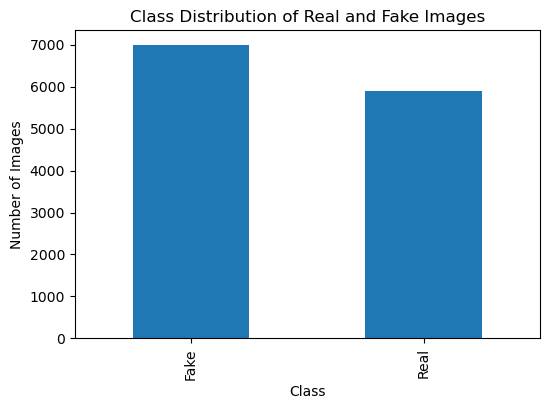

label
Fake    7000
Real    5890
Name: count, dtype: int64


In [50]:
class_counts = df["label"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")

plt.title("Class Distribution of Real and Fake Images")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

print(class_counts)

The dataset contains more fake images than real images. However, the difference is not extremely large, so the dataset can still be used for training a binary classification model.

## Visualizing Sample Images from the Dataset

Before training the model, it is important to view some sample images from both classes. This helps us understand the dataset and confirm that the images have been loaded correctly.

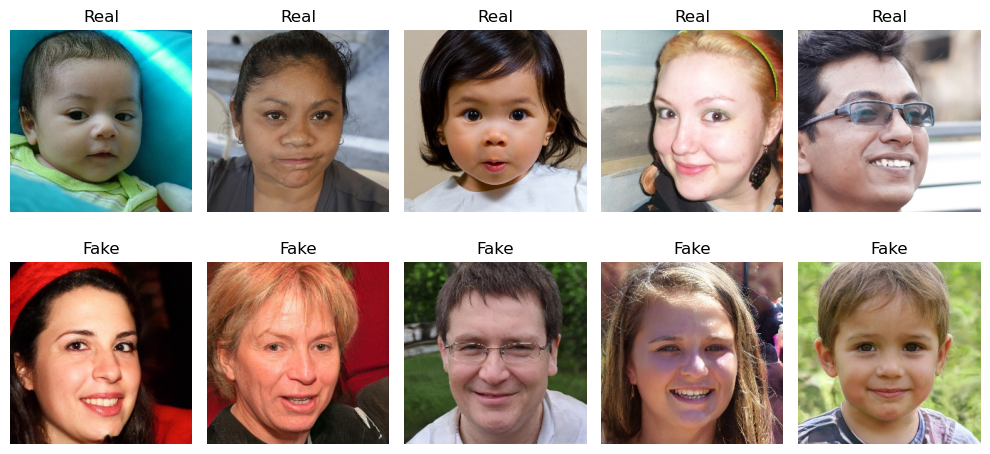

In [51]:
plt.figure(figsize=(10, 5))

for i in range(5):
    img_path = os.path.join(real_path, real_images[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title("Real")
    plt.axis("off")

for i in range(5):
    img_path = os.path.join(fake_path, fake_images[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 6)
    plt.imshow(img)
    plt.title("Fake")
    plt.axis("off")

plt.tight_layout()
plt.show()

The sample images from both classes have been displayed successfully. The first row shows real face images, while the second row shows fake face images. This confirms that the dataset folders are correctly loaded and the images can be read by the program.

## Data Cleaning

Data cleaning is an important step before training the model. In this section, we check the dataset for missing values, duplicate records, invalid labels, and corrupted image files. This helps ensure that the model is trained on clean and reliable data.

In [52]:
clean_data = []

#real image paths
for img_name in os.listdir(real_path):
    clean_data.append({
        "image_path": os.path.join(real_path, img_name),
        "label": "Real"
    })

#fake image paths
for img_name in os.listdir(fake_path):
    clean_data.append({
        "image_path": os.path.join(fake_path, img_name),
        "label": "Fake"
    })

clean_df = pd.DataFrame(clean_data)

clean_df.head()

,image_path,label
0,.\Real\00000.jpg,Real
1,.\Real\00002.jpg,Real
2,.\Real\00003.jpg,Real
3,.\Real\00006.jpg,Real
4,.\Real\00009.jpg,Real


### Checking Missing Values

Missing values can cause errors during image loading and model training. In this step, we check whether any image path or label is missing.

In [53]:
print("Missing values in each column:")
print(clean_df.isnull().sum())

Missing values in each column:
image_path    0
label         0
dtype: int64


### Checking Duplicate Records

Duplicate records may affect model training because the same image path can appear more than once. In this step, we check and remove duplicate records if they exist.

In [54]:
print("Duplicate records before cleaning:", clean_df.duplicated().sum())

clean_df = clean_df.drop_duplicates()

print("Duplicate records after cleaning:", clean_df.duplicated().sum())
print("Dataset shape after removing duplicates:", clean_df.shape)

Duplicate records before cleaning: 0
Duplicate records after cleaning: 0
Dataset shape after removing duplicates: (12890, 2)


### Checking Class Labels

The dataset should contain only two labels: Real and Fake. This step verifies that there are no incorrect or unexpected labels.

In [55]:
print("Unique labels in the dataset:")
print(clean_df["label"].unique())

print("\nClass distribution:")
print(clean_df["label"].value_counts())

Unique labels in the dataset:
['Real' 'Fake']

Class distribution:
label
Fake    7000
Real    5890
Name: count, dtype: int64


### Checking Corrupted Images

Since this is an image dataset, some image files may be unreadable or corrupted. In this step, each image is checked using OpenCV. If an image cannot be read, it is removed from the dataset.

In [56]:
valid_data = []
corrupted_images = []

for index, row in clean_df.iterrows():
    img_path = row["image_path"]
    label = row["label"]
    
    img = cv2.imread(img_path)
    
    if img is not None:
        valid_data.append({
            "image_path": img_path,
            "label": label
        })
    else:
        corrupted_images.append(img_path)

clean_df = pd.DataFrame(valid_data)

print("Number of corrupted images:", len(corrupted_images))
print("Dataset shape after removing corrupted images:", clean_df.shape)

Number of corrupted images: 0
Dataset shape after removing corrupted images: (12890, 2)


### Data Cleaning Summary

The data cleaning process has been completed successfully. The dataset was checked for missing values, duplicate records, class labels, and corrupted image files.

The results show that there are no missing values in the image paths or labels. No duplicate records were found in the dataset. The dataset contains only two valid class labels: Real and Fake. The corrupted image check also shows that all images are readable, and no corrupted images were found.

After data cleaning, the dataset still contains 12,890 valid images with 2 columns: image_path and label. Therefore, the dataset is clean and ready for image preprocessing.

### Cleaned Dataset

In [57]:
clean_df.head()

,image_path,label
0,.\Real\00000.jpg,Real
1,.\Real\00002.jpg,Real
2,.\Real\00003.jpg,Real
3,.\Real\00006.jpg,Real
4,.\Real\00009.jpg,Real


In [58]:
print("Final cleaned dataset shape:", clean_df.shape)
print("Final class distribution:")
print(clean_df["label"].value_counts())

Final cleaned dataset shape: (12890, 2)
Final class distribution:
label
Fake    7000
Real    5890
Name: count, dtype: int64


###  Result and Observation

The cleaned dataset contains 12,890 valid image records with two columns: image_path and label. The dataset includes 7,000 fake images and 5,890 real images. No records were removed during cleaning because there were no missing values, duplicate records, or corrupted images.

This cleaned dataset will now be used for image preprocessing and model training.

## Image Preprocessing

Image preprocessing prepares the images for model training. In this step, each image is resized to a fixed size, converted into a NumPy array, and normalized.

Resizing is required because all images must have the same dimensions before being passed to the model. Normalization converts pixel values from the range 0–255 to the range 0–1, which helps the model train more efficiently.

In [59]:
IMG_SIZE = 128

print("Image size selected:", IMG_SIZE, "x", IMG_SIZE)

Image size selected: 128 x 128


### Encoding Class Labels

Machine learning models work with numerical values, so the class labels are converted into numbers. In this project, Real is represented as 0 and Fake is represented as 1.

In [60]:
label_map = {
    "Real": 0,
    "Fake": 1
}

clean_df["label_encoded"] = clean_df["label"].map(label_map)

clean_df.head()

,image_path,label,label_encoded
0,.\Real\00000.jpg,Real,0
1,.\Real\00002.jpg,Real,0
2,.\Real\00003.jpg,Real,0
3,.\Real\00006.jpg,Real,0
4,.\Real\00009.jpg,Real,0


In [61]:
print("Encoded label distribution:")
print(clean_df["label_encoded"].value_counts())

Encoded label distribution:
label_encoded
1    7000
0    5890
Name: count, dtype: int64


The labels have been successfully encoded into numerical values. The Real class is represented by 0, while the Fake class is represented by 1. These encoded labels will be used as the target variable for model training.

### Loading, Resizing, and Normalizing Images

In this step, each image is loaded from its path, converted from BGR to RGB format, resized to 128x128 pixels, and normalized by dividing pixel values by 255. The processed images are stored in X, while the encoded labels are stored in y.

In [63]:
X = []
y = []

for index, row in clean_df.iterrows():
    img_path = row["image_path"]
    label = row["label_encoded"]
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    
    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Image data shape:", X.shape)
print("Label data shape:", y.shape)

Image data shape: (12890, 128, 128, 3)
Label data shape: (12890,)


### Basic Image Data Statistics

Since this is an image dataset, traditional statistical analysis such as mean, median, and correlation is not very useful. Instead, basic image statistics are calculated on pixel values after normalization.

In [85]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())
print("Mean pixel value:", X.mean())
print("Standard deviation of pixel values:", X.std())

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Mean pixel value: 0.418851847926792
Standard deviation of pixel values: 0.2753747103362327


## Model Development Plan

In this project, three different models will be used for DeepFake face image detection.

1. Random Forest Classifier  
   This is a traditional machine learning algorithm used as a baseline model.

2. Convolutional Neural Network  
   CNN is a deep learning model suitable for image classification because it can learn visual patterns from images.

3. ResNet50 Transfer Learning  
   ResNet50 is a pre-trained deep learning model that can improve performance by using features learned from a large image dataset.

The models will be evaluated using accuracy, precision, recall, F1-score, confusion matrix, ROC curve, and AUC score.

## Splitting the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate model performance on unseen data.

In this project, 80% of the data is used for training and 20% is used for testing. Stratified splitting is used to maintain the same Real and Fake class ratio in both sets.

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training image data shape:", X_train.shape)
print("Testing image data shape:", X_test.shape)
print("Training label data shape:", y_train.shape)
print("Testing label data shape:", y_test.shape)

Training image data shape: (10312, 128, 128, 3)
Testing image data shape: (2578, 128, 128, 3)
Training label data shape: (10312,)
Testing label data shape: (2578,)


### Verifying Train-Test Class Distribution

After splitting the dataset, we check the class distribution in the training and testing sets. This ensures that both Real and Fake classes are properly represented in both sets.

In [65]:
train_counts = pd.Series(y_train).value_counts()
test_counts = pd.Series(y_test).value_counts()

print("Training set class distribution:")
print(train_counts)

print("\nTesting set class distribution:")
print(test_counts)

Training set class distribution:
1    5600
0    4712
Name: count, dtype: int64

Testing set class distribution:
1    1400
0    1178
Name: count, dtype: int64


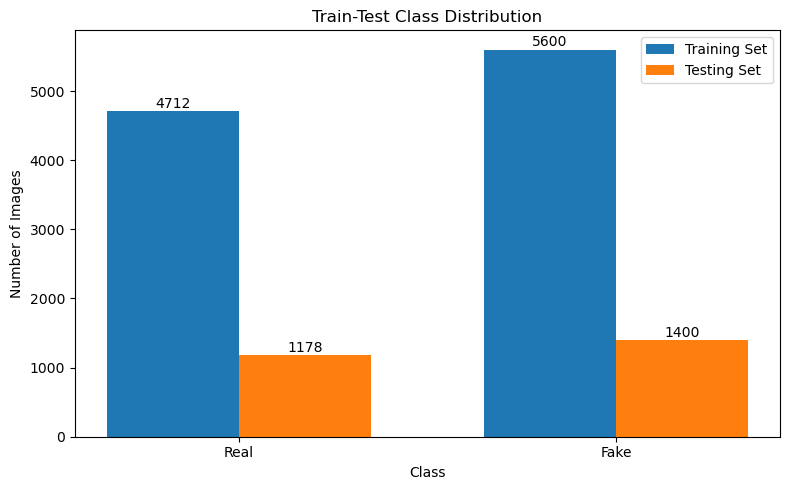

In [66]:
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

labels = ["Real", "Fake"]
train_values = [train_counts[0], train_counts[1]]
test_values = [test_counts[0], test_counts[1]]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, train_values, width, label="Training Set")
plt.bar(x + width/2, test_values, width, label="Testing Set")

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Train-Test Class Distribution")
plt.xticks(x, labels)
plt.legend()

for i in range(len(labels)):
    plt.text(x[i] - width/2, train_values[i] + 50, str(train_values[i]), ha="center")
    plt.text(x[i] + width/2, test_values[i] + 50, str(test_values[i]), ha="center")

plt.tight_layout()
plt.show()

The graph shows that both Real and Fake classes are properly represented in the training and testing sets. Since stratified splitting was used, the class ratio is preserved in both sets, which helps the model learn and evaluate fairly.

## Model 1: Random Forest Classifier

Random Forest is a traditional machine learning algorithm used as a baseline model in this project. Since Random Forest cannot directly process image data in 3D format, the images are resized to a smaller size and flattened into one-dimensional feature vectors.

This model helps us compare traditional machine learning performance with deep learning models such as CNN and ResNet50.

In [67]:
# Resize images to 32x32 for Random Forest to reduce feature size

RF_SIZE = 32

X_train_rf = np.array([cv2.resize(img, (RF_SIZE, RF_SIZE)) for img in X_train])
X_test_rf = np.array([cv2.resize(img, (RF_SIZE, RF_SIZE)) for img in X_test])

# Flatten images
X_train_rf = X_train_rf.reshape(X_train_rf.shape[0], -1)
X_test_rf = X_test_rf.reshape(X_test_rf.shape[0], -1)

print("Random Forest training data shape:", X_train_rf.shape)
print("Random Forest testing data shape:", X_test_rf.shape)

Random Forest training data shape: (10312, 3072)
Random Forest testing data shape: (2578, 3072)


In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


### Evaluating the Random Forest Model

After training the Random Forest model, we evaluate its performance on the testing data. The evaluation includes accuracy, precision, recall, F1-score, confusion matrix, ROC curve, and AUC score.

In [69]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

# Predict test labels
y_pred_rf = rf_model.predict(X_test_rf)

# Predict probabilities for ROC curve
y_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Real", "Fake"]))

Random Forest Accuracy: 0.7168347556245152

Classification Report:
              precision    recall  f1-score   support

        Real       0.70      0.65      0.68      1178
        Fake       0.73      0.77      0.75      1400

    accuracy                           0.72      2578
   macro avg       0.72      0.71      0.71      2578
weighted avg       0.72      0.72      0.72      2578



### Random Forest Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the Random Forest model for both Real and Fake classes.

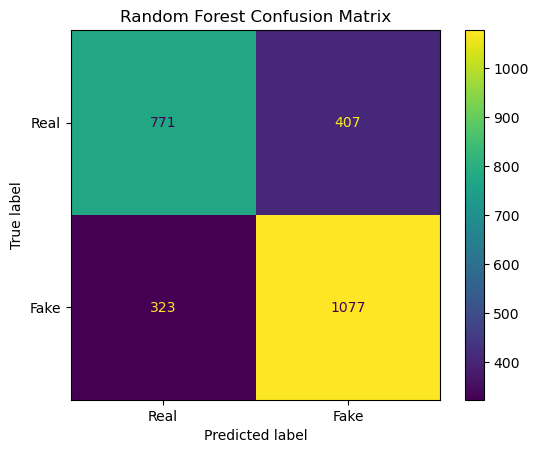

In [70]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Real", "Fake"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

### Random Forest ROC Curve and AUC Score

The ROC curve shows the model's ability to distinguish between Real and Fake images. The AUC score summarizes the overall classification performance of the model.

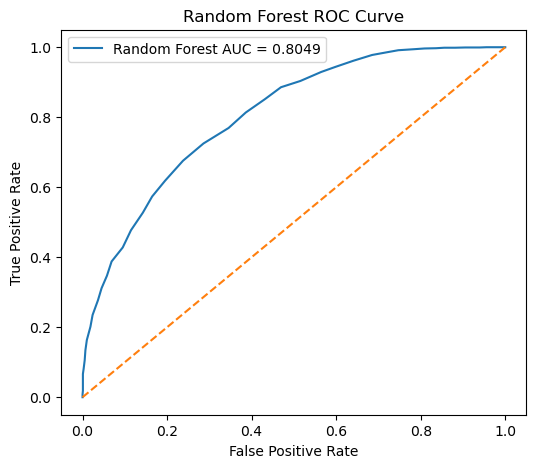

Random Forest AUC Score: 0.80494936939122


In [71]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

print("Random Forest AUC Score:", auc_rf)

### Random Forest Result Summary

The Random Forest model achieved an accuracy of approximately 71.68% on the testing dataset. The classification report shows that the model performed slightly better on the Fake class compared to the Real class.

From the confusion matrix, the model correctly classified 771 real images and 1077 fake images. However, it misclassified 407 real images as fake and 323 fake images as real.

The ROC curve shows an AUC score of 0.8049, which indicates that the Random Forest model has a reasonable ability to separate Real and Fake images. Since Random Forest is a traditional machine learning model and does not learn spatial image features like a CNN, it will be used as a baseline model for comparison.

## Model 2: Convolutional Neural Network

A Convolutional Neural Network is a deep learning model commonly used for image classification tasks. Unlike traditional machine learning models, CNNs can automatically learn important visual features such as edges, textures, shapes, and patterns from images.

In this project, the CNN model is used to classify face images as Real or Fake.

In [72]:
%pip install tensorflow

^C
Note: you may need to restart the kernel to use updated packages.


In [73]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### Importing CNN Libraries

In this step, we import the required TensorFlow and Keras libraries for building the Convolutional Neural Network model.

In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("CNN libraries imported successfully")

CNN libraries imported successfully


### Building the CNN Model

The CNN model contains convolutional layers for feature extraction, max pooling layers for reducing image dimensions, dropout to reduce overfitting, and dense layers for final classification.

In [ ]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

cnn_model.summary()

### Compiling the CNN Model

The model is compiled using the Adam optimizer and binary crossentropy loss function because this is a binary classification problem with two classes: Real and Fake.

In [76]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully")

CNN model compiled successfully


### CNN Model Result

The CNN model has been built and compiled successfully. The model contains convolutional layers for feature extraction, max pooling layers for reducing image size, a flatten layer, dense layers for classification, and dropout to reduce overfitting.

The model has 3,304,769 trainable parameters. TensorFlow is currently running on CPU, so training may take more time compared to GPU training.

In [77]:
history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 150s 567ms/step - accuracy: 0.5963 - loss: 0.6696 - val_accuracy: 0.6830 - val_loss: 0.6130
Epoch 2/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 89s 346ms/step - accuracy: 0.6909 - loss: 0.5859 - val_accuracy: 0.7213 - val_loss: 0.5441
Epoch 3/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 70s 270ms/step - accuracy: 0.7372 - loss: 0.5134 - val_accuracy: 0.7431 - val_loss: 0.4994
Epoch 4/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 72s 281ms/step - accuracy: 0.7695 - loss: 0.4606 - val_accuracy: 0.7441 - val_loss: 0.4954
Epoch 5/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 73s 284ms/step - accuracy: 0.7992 - loss: 0.4113 - val_accuracy: 0.7746 - val_loss: 0.4577


### CNN Training Result 

The CNN model was trained for 5 epochs. During training, the accuracy increased from 59.63% to 79.92%, while the validation accuracy improved from 68.30% to 77.46%. The training loss and validation loss also decreased, which shows that the model learned useful patterns from the image dataset.

### CNN Accuracy and Loss Graphs

The accuracy and loss graphs show how the CNN model performed during training. Accuracy should increase over epochs, while loss should decrease.

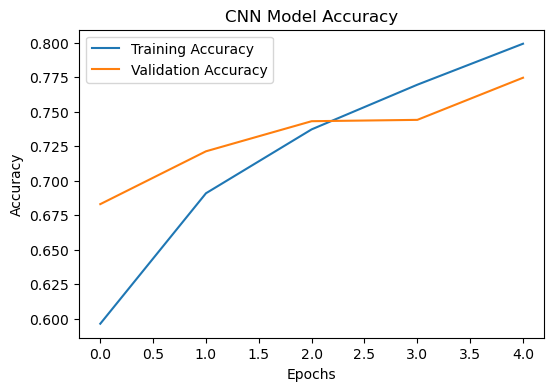

In [78]:
plt.figure(figsize=(6, 4))

plt.plot(history_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

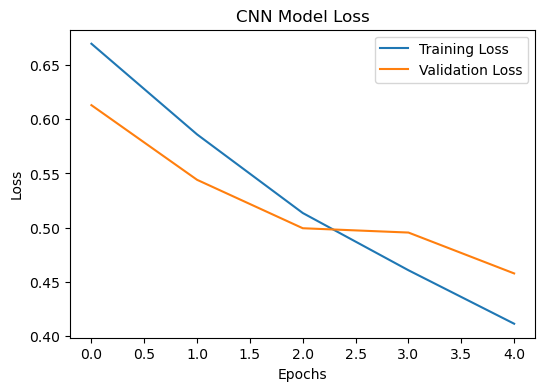

In [79]:
plt.figure(figsize=(6, 4))

plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")

plt.title("CNN Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### CNN Accuracy and Loss Graph Result

The CNN accuracy graph shows that both training accuracy and validation accuracy increased across the 5 epochs. This means the model gradually learned useful image features for classifying Real and Fake faces.

The CNN loss graph shows that both training loss and validation loss decreased over time. This is a positive sign because lower loss means the model is making fewer errors during training and validation.

Overall, the graphs show that the CNN model is learning well and is not showing strong overfitting within 5 epochs.

### Evaluating the CNN Model on Test Data

After training, the CNN model is evaluated on the testing dataset. This step shows how well the model performs on unseen images.

In [80]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test, y_test)

print("CNN Test Accuracy:", cnn_accuracy)
print("CNN Test Loss:", cnn_loss)

81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.7680 - loss: 0.4463
CNN Test Accuracy: 0.7680372595787048
CNN Test Loss: 0.44633105397224426


### CNN Classification Report

The classification report shows precision, recall, and F1-score for both Real and Fake classes.

In [81]:
y_prob_cnn = cnn_model.predict(X_test)
y_pred_cnn = (y_prob_cnn > 0.5).astype("int32").flatten()

print("CNN Classification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=["Real", "Fake"]))

81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step
CNN Classification Report:
              precision    recall  f1-score   support

        Real       0.79      0.67      0.73      1178
        Fake       0.76      0.85      0.80      1400

    accuracy                           0.77      2578
   macro avg       0.77      0.76      0.76      2578
weighted avg       0.77      0.77      0.77      2578



### Result and Observations
The CNN model achieved an accuracy of approximately 77% on the testing dataset. The model performed better than the Random Forest baseline model.

For the Real class, the model achieved a precision of 0.79 and recall of 0.67. For the Fake class, the model achieved a precision of 0.76 and recall of 0.85. This shows that the CNN model is better at correctly identifying Fake images compared to Real images.

### CNN Confusion Matrix

The confusion matrix shows how many Real and Fake images were correctly and incorrectly classified by the CNN model.

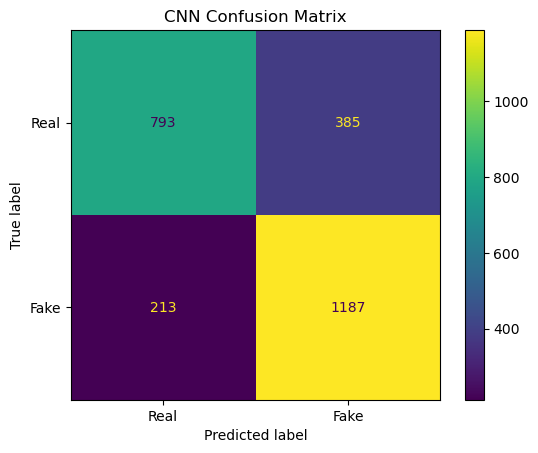

In [82]:
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=["Real", "Fake"]
)

disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

### CNN ROC Curve and AUC Score

The ROC curve shows how well the CNN model separates Real and Fake images. The AUC score gives an overall measure of the model's classification performance.

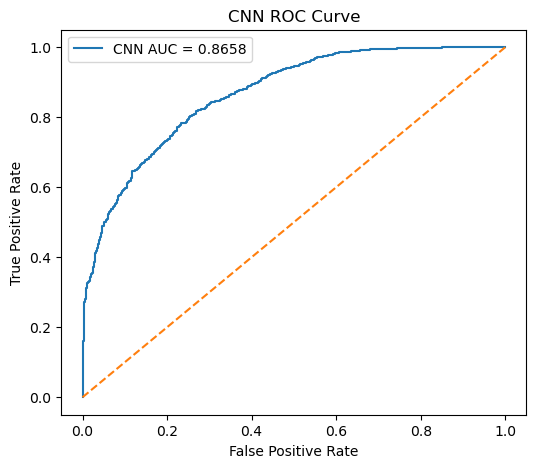

CNN AUC Score: 0.8657943245209798


In [84]:
fpr_cnn, tpr_cnn, thresholds_cnn = roc_curve(y_test, y_prob_cnn)
auc_cnn = auc(fpr_cnn, tpr_cnn)

plt.figure(figsize=(6, 5))
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN AUC = {auc_cnn:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN ROC Curve")
plt.legend()
plt.show()

print("CNN AUC Score:", auc_cnn)

### CNN Result Summary

The CNN model achieved better performance than the Random Forest model. The CNN reached an AUC score of approximately 0.8658, which shows that it has a strong ability to separate Real and Fake images.

The model performed especially well in detecting Fake images, as shown by the higher recall for the Fake class. This means the CNN was able to correctly identify most fake face images in the testing dataset.

Compared to Random Forest, CNN is more suitable for this task because it can automatically learn spatial and visual features from images such as facial patterns, textures, edges, and artificial generation artifacts.

## Model Comparison

In [86]:
model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "CNN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        cnn_accuracy
    ],
    "AUC Score": [
        auc_rf,
        auc_cnn
    ]
})

model_comparison

,Model,Accuracy,AUC Score
0,Random Forest,0.716835,0.804949
1,CNN,0.768037,0.865794


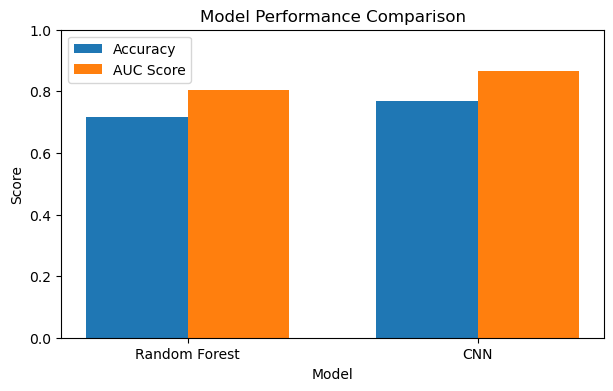

In [87]:
plt.figure(figsize=(7, 4))

x = np.arange(len(model_comparison["Model"]))
width = 0.35

plt.bar(x - width/2, model_comparison["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, model_comparison["AUC Score"], width, label="AUC Score")

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(x, model_comparison["Model"])
plt.legend()
plt.ylim(0, 1)

plt.show()

### Model Comparison Summary

The model comparison shows that the CNN model performed better than the Random Forest model. Random Forest was used as a baseline traditional machine learning model, while CNN was used as the main deep learning model.

The CNN model achieved higher accuracy and a higher AUC score, which indicates that it is better at learning visual features from face images. Therefore, CNN is more suitable for DeepFake face image detection than Random Forest.

## Model 3: ResNet50 Transfer Learning

ResNet50 is a deep convolutional neural network that has already been trained on a large image dataset. Instead of training the entire model from scratch, we use transfer learning. This means the pre-trained ResNet50 model is used as a feature extractor, and only the final classification layers are trained for our DeepFake detection task.

This approach can improve performance because ResNet50 has already learned useful image features such as edges, shapes, textures, and patterns.

### Importing ResNet50 Libraries

In this step, we import the required libraries for using the ResNet50 pre-trained model.

In [88]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

print("ResNet50 libraries imported successfully")

ResNet50 libraries imported successfully


### Preparing Data for ResNet50

ResNet50 requires image data to be preprocessed using its own preprocessing function. Since our images are already resized to 128x128 pixels, we only apply ResNet50 preprocessing to the training and testing data.

In [89]:
X_train_resnet = preprocess_input(X_train * 255.0)
X_test_resnet = preprocess_input(X_test * 255.0)

print("ResNet50 training data shape:", X_train_resnet.shape)
print("ResNet50 testing data shape:", X_test_resnet.shape)

ResNet50 training data shape: (10312, 128, 128, 3)
ResNet50 testing data shape: (2578, 128, 128, 3)


### Building the ResNet50 Transfer Learning Model

The ResNet50 base model is loaded without its original top classification layer. The base model is frozen so that its pre-trained weights are not updated during training. New classification layers are added for the Real and Fake image classification task.

In [90]:
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freeze the ResNet50 base model
resnet_base.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

resnet_model = Model(inputs=resnet_base.input, outputs=output)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 198s 2us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Compiling the ResNet50 Model

The ResNet50 transfer learning model is compiled using the Adam optimizer and binary crossentropy loss function. Binary crossentropy is used because this is a binary classification task with two classes: Real and Fake.

In [91]:
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("ResNet50 model compiled successfully")

ResNet50 model compiled successfully


### Training the ResNet50 Model

The ResNet50 model is trained using the preprocessed training data. Since the base model is frozen, only the newly added classification layers are trained. This makes training faster and more suitable for a normal laptop.

In [92]:
history_resnet = resnet_model.fit(
    X_train_resnet, y_train,
    epochs=5,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 316s 590ms/step - accuracy: 0.7034 - loss: 0.6082 - val_accuracy: 0.7998 - val_loss: 0.4307
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 287s 557ms/step - accuracy: 0.7840 - loss: 0.4406 - val_accuracy: 0.8211 - val_loss: 0.3874
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 355s 621ms/step - accuracy: 0.8109 - loss: 0.3917 - val_accuracy: 0.8274 - val_loss: 0.3592
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 260s 500ms/step - accuracy: 0.8288 - loss: 0.3623 - val_accuracy: 0.8371 - val_loss: 0.3453
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 264s 511ms/step - accuracy: 0.8388 - loss: 0.3421 - val_accuracy: 0.8434 - val_loss: 0.3357


### ResNet50 Training Result 

The ResNet50 transfer learning model was trained for 5 epochs. The training accuracy increased from 70.34% to 83.88%, while the validation accuracy improved from 79.98% to 84.34%.

The validation loss also decreased from 0.4307 to 0.3357. This shows that the ResNet50 model learned useful features for DeepFake detection and performed better than both Random Forest and the custom CNN model.

### ResNet50 Accuracy and Loss Graphs

The accuracy and loss graphs show the learning progress of the ResNet50 transfer learning model during training.

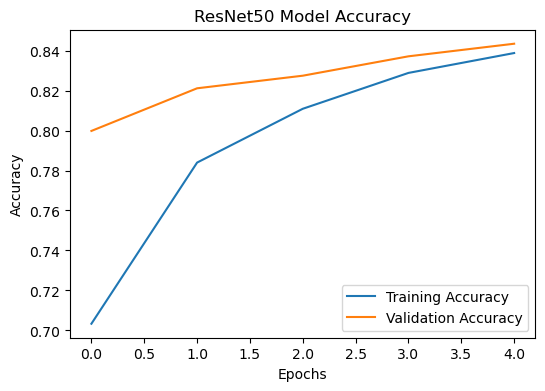

In [93]:
plt.figure(figsize=(6, 4))

plt.plot(history_resnet.history["accuracy"], label="Training Accuracy")
plt.plot(history_resnet.history["val_accuracy"], label="Validation Accuracy")

plt.title("ResNet50 Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

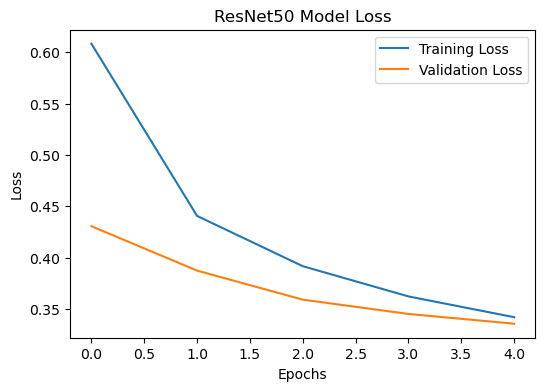

In [94]:
plt.figure(figsize=(6, 4))

plt.plot(history_resnet.history["loss"], label="Training Loss")
plt.plot(history_resnet.history["val_loss"], label="Validation Loss")

plt.title("ResNet50 Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Evaluating the ResNet50 Model on Test Data

After training, the ResNet50 model is evaluated on the testing dataset to check its performance on unseen images.

In [95]:
resnet_loss, resnet_accuracy = resnet_model.evaluate(X_test_resnet, y_test)

print("ResNet50 Test Accuracy:", resnet_accuracy)
print("ResNet50 Test Loss:", resnet_loss)

81/81 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8476 - loss: 0.3424
ResNet50 Test Accuracy: 0.8475562334060669
ResNet50 Test Loss: 0.34235358238220215


### ResNet50 Test Result 

The ResNet50 transfer learning model achieved a test accuracy of approximately 84.76%. This is higher than both the Random Forest and CNN models, which shows that transfer learning performed better for DeepFake face image detection.

The test loss is 0.3424, which is also lower than the CNN test loss. This indicates that ResNet50 made fewer errors on unseen test images.

### ResNet50 Classification Report

The classification report shows the precision, recall, and F1-score of the ResNet50 model for both Real and Fake classes.

In [96]:
y_prob_resnet = resnet_model.predict(X_test_resnet)
y_pred_resnet = (y_prob_resnet > 0.5).astype("int32").flatten()

print("ResNet50 Classification Report:")
print(classification_report(y_test, y_pred_resnet, target_names=["Real", "Fake"]))

81/81 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step
ResNet50 Classification Report:
              precision    recall  f1-score   support

        Real       0.86      0.80      0.83      1178
        Fake       0.84      0.89      0.86      1400

    accuracy                           0.85      2578
   macro avg       0.85      0.84      0.85      2578
weighted avg       0.85      0.85      0.85      2578



### ResNet50 Confusion Matrix

The confusion matrix shows how many Real and Fake images were correctly and incorrectly classified by the ResNet50 model.

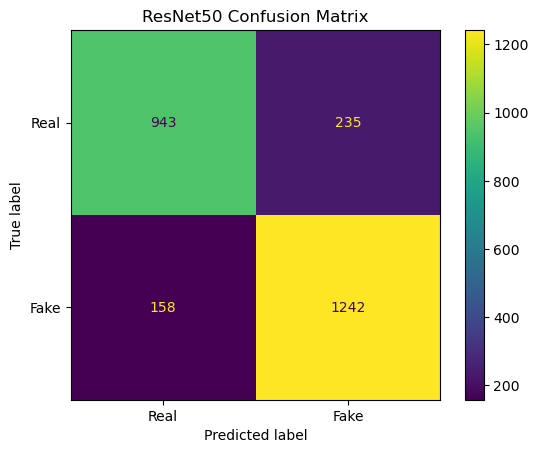

In [97]:
cm_resnet = confusion_matrix(y_test, y_pred_resnet)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_resnet,
    display_labels=["Real", "Fake"]
)

disp.plot()
plt.title("ResNet50 Confusion Matrix")
plt.show()

### ResNet50 ROC Curve and AUC Score

The ROC curve shows the ability of the ResNet50 model to separate Real and Fake images. The AUC score gives an overall performance measure of the model.

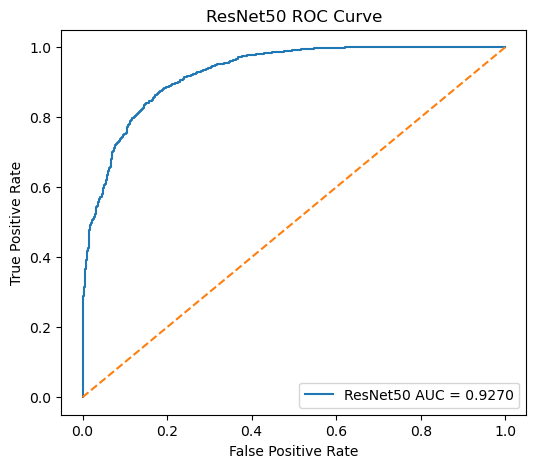

ResNet50 AUC Score: 0.9269718651467377


In [98]:
fpr_resnet, tpr_resnet, thresholds_resnet = roc_curve(y_test, y_prob_resnet)
auc_resnet = auc(fpr_resnet, tpr_resnet)

plt.figure(figsize=(6, 5))
plt.plot(fpr_resnet, tpr_resnet, label=f"ResNet50 AUC = {auc_resnet:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 ROC Curve")
plt.legend()
plt.show()

print("ResNet50 AUC Score:", auc_resnet)

### ResNet50 Result 

The ResNet50 transfer learning model achieved the best performance among all models. It achieved a test accuracy of approximately 84.76% and an AUC score of 0.9270.

The high AUC score shows that ResNet50 has a strong ability to distinguish between Real and Fake face images. Since ResNet50 is a pre-trained deep learning model, it can extract more powerful visual features compared to the custom CNN and Random Forest model.

## Final Model Comparison

In this section, the performance of all three models is compared. The comparison includes accuracy and AUC score. This helps identify which model performed best for DeepFake face image detection.

In [99]:
model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "CNN", "ResNet50"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        cnn_accuracy,
        resnet_accuracy
    ],
    "AUC Score": [
        auc_rf,
        auc_cnn,
        auc_resnet
    ]
})

model_comparison

,Model,Accuracy,AUC Score
0,Random Forest,0.716835,0.804949
1,CNN,0.768037,0.865794
2,ResNet50,0.847556,0.926972


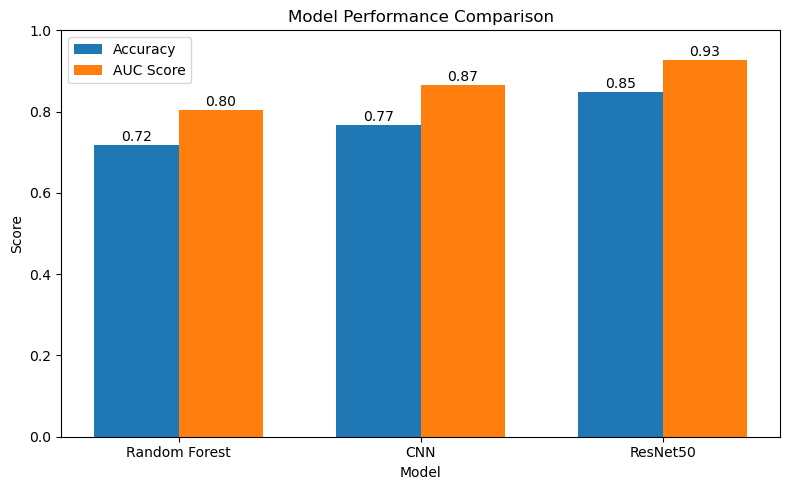

In [100]:
x = np.arange(len(model_comparison["Model"]))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, model_comparison["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, model_comparison["AUC Score"], width, label="AUC Score")

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(x, model_comparison["Model"])
plt.ylim(0, 1)
plt.legend()

for i in range(len(model_comparison)):
    plt.text(x[i] - width/2, model_comparison["Accuracy"][i] + 0.01,
             f'{model_comparison["Accuracy"][i]:.2f}', ha="center")
    plt.text(x[i] + width/2, model_comparison["AUC Score"][i] + 0.01,
             f'{model_comparison["AUC Score"][i]:.2f}', ha="center")

plt.tight_layout()
plt.show()

### Final Model Comparison 

The comparison shows that ResNet50 achieved the highest accuracy and AUC score among the three models. Random Forest performed reasonably as a baseline model, while CNN performed better because it can learn visual patterns from images.

ResNet50 produced the best result because it uses transfer learning from a pre-trained deep learning model. Therefore, ResNet50 is selected as the best-performing model for this DeepFake face image detection project.

## Testing the Best Model on a New Image

After comparing all models, ResNet50 was selected as the best-performing model. In this section, the trained ResNet50 model is tested on a single new image. The image is loaded, resized, preprocessed, and passed to the model for prediction.

In [ ]:
def predict_deepfake_resnet(image_path):
    img = cv2.imread(image_path)
    
    if img is None:
        print("Image not found or unable to read image.")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    
    img_array = np.array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    prediction = resnet_model.predict(img_array)[0][0]
    
    if prediction >= 0.5:
        result = "Fake"
    else:
        result = "Real"
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {result} ({prediction:.4f})")
    plt.axis("off")
    plt.show()
    
    print("Prediction Score:", prediction)
    print("Predicted Class:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


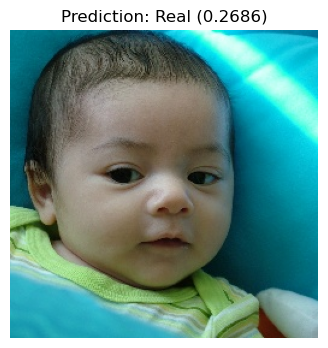

Prediction Score: 0.2686394
Predicted Class: Real


In [102]:
test_image_path = clean_df["image_path"].iloc[0]

predict_deepfake_resnet(test_image_path)

The best-performing ResNet50 model was tested on a single image. The model displayed the image and predicted whether it belongs to the Real or Fake class. This confirms that the trained model can be used for individual image prediction.

### Testing on a New External Image

In this step, the best-performing ResNet50 model is tested on a new external image that was not directly selected from the dataset. The image is loaded from the local system, resized, preprocessed, and passed to the trained model for prediction.

In [140]:
def predict_new_image_resnet(image_path, threshold=0.3):
    img = cv2.imread(image_path)
    
    if img is None:
        print("Image not found. Please check the image path.")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    
    img_array = np.array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    fake_probability = resnet_model.predict(img_array)[0][0]
    
    if fake_probability >= threshold:
        result = "Fake"
        confidence = fake_probability
    else:
        result = "Real"
        confidence = 1 - fake_probability
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {result}\nConfidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()
    
    print("Fake Probability:", fake_probability)
    print("Predicted Class:", result)
    print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


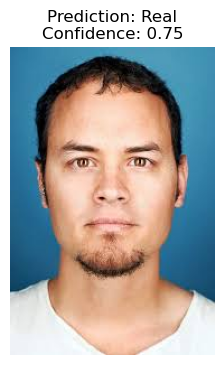

Fake Probability: 0.2510948
Predicted Class: Real
Confidence: 0.7489052


In [141]:
new_image_path = "real_image1.JPG"

predict_new_image_resnet(new_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


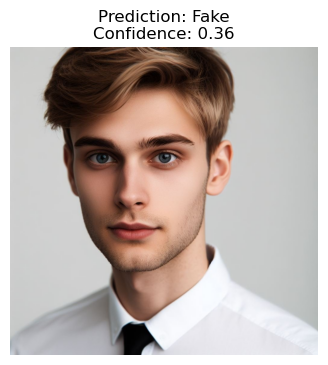

Fake Probability: 0.36201584
Predicted Class: Fake
Confidence: 0.36201584


In [142]:
new_image_path = "fake_image.JPG"

predict_new_image_resnet(new_image_path)